# Notebook for evaluating SPR Verification metrics described in \<DOCUMENT NUMBER\>

In [1]:
# 
# Import dependencies
#

import numpy as np
import matplotlib.pyplot as plt
import pickle

from astropy.cosmology import Planck18
from astropy import units as u

from lisatools.utils.constants import *
from lisatools.sensitivity import get_sensitivity, A1TDISens
from lisatools.detector import mrdv1, scirdv1, Orbits, DefaultOrbits, LISAModel, EqualArmlengthOrbits
from lisatools.sources import BBHCalculationController, GBCalculationController, EMRICalculationController
from lisatools.sources.emri import EMRITDIWaveform
from lisatools.sources.bbh import BBHSNRWaveform
from lisatools.sources.gb import GBAETWaveform

from eryn.prior import uniform_dist, ProbDistContainer
from eryn.utils import TransformContainer

from gen_gb_pe_dist import run_posterior_estimate_vgbs
from download_kgbs import download_new_gbs_dataset
import h5py
import os

import pandas as pd

No CuPy


In [2]:
# 
# Setup detector model
#

orbits_here = EqualArmlengthOrbits()
noise = scirdv1
Tobs = 1.0 * YRSID_SI
dt = 10.0
Nobs = int(Tobs / dt)
Tobs = Nobs * dt

psd_kwargs = dict(
    stochastic_params=(Tobs,),
)

In [3]:
#
# Setup waveform models
#
calculators = {}

# black hole generator
bbh = BBHSNRWaveform(response_kwargs=dict(TDItag="AET", orbits=orbits_here, tdi2=False))

calculators["bbh"] = BBHCalculationController(
    bbh, 
    noise,
    psd_kwargs, 
    Tobs / YRSID_SI,
    dt,
    psd=A1TDISens
)

# gb generator
gb = GBAETWaveform(orbits=orbits_here)

calculators["gb"] = GBCalculationController(
    gb, 
    noise,
    psd_kwargs, 
    Tobs / YRSID_SI,
    dt,
    psd=A1TDISens
)


# emri generator
emri = EMRITDIWaveform(
    T=Tobs / YRSID_SI, 
    dt=dt, 
    emri_waveform_kwargs=dict(inspiral_kwargs=dict(integrate_backwards=True)),
    response_kwargs=dict(tdi="1st generation", orbits=orbits_here)
)

calculators["emri"] = EMRICalculationController(
    emri, 
    scirdv1,
    psd_kwargs, 
    Tobs / YRSID_SI,
    dt,
    psd=A1TDISens
)

## SPR-1: LISA shall measure the GW amplitude of the known UCB systems AM CVn, SDSS J1908, HP Lib, V803 Cen, J0526+5934, HM Cnc to better than 10%

FOM 1: A table including the input binary parameters, the percent error on the GW amplitude for a 1 year observation as approximated by the information matrix, and the observation time needed to achieve the desired amplitude precision.

FOM 2: A marginalized posterior distribution function in amplitude-inclination for a 1 year observation of AM CVn compared to the information matrix estimate to spot check the estimate.

In [4]:
# load the VGBs of interest
import pandas as pd

# get newest versions of the 
download_new_gbs_dataset()

df = pd.DataFrame(np.load("vgbs/VGB.npy"))

Successfully unzipped 'vgbs.zip' to './vgbs'


In [5]:
df

,Name,Amplitude,Frequency,FrequencyDerivative,EclipticLatitude,EclipticLongitude,Inclination,ErrorInclination,Polarization,InitialPhase,GalacticLatitude,GalacticLongitude,Period,Mass1,ErrorMass1,Mass2,ErrorMass2,Distance,ErrorDistance
0,HMCnc,4.252226e-23,0.006220,7.485269e-16,-0.082100,2.102051,0.663225,0.000,0.0,0.0,0.408323,3.611516,321.529129,0.550,0.0000,0.270,0.0000,7500.000,2500.000000
1,ZTFJ1539,9.402415e-23,0.004822,2.537825e-16,1.154738,3.578407,1.468695,0.605,0.0,0.0,0.882821,1.409783,414.791540,0.610,0.0195,0.210,0.0150,2469.000,1253.000000
2,ZTFJ2243,1.222493e-22,0.003788,1.138206e-16,0.941778,0.231054,1.429076,1.000,0.0,0.0,-0.095113,1.817785,527.934890,0.349,0.0835,0.384,0.0940,1756.000,726.000000
3,V407Vul,9.381080e-23,0.003512,8.282059e-17,0.816522,5.148558,1.047198,0.000,0.0,0.0,0.111712,1.007545,569.396230,0.800,0.1000,0.177,0.0710,2089.000,684.000000
4,ESCet,9.517180e-23,0.003225,5.536766e-17,-0.354893,0.429491,1.047198,0.000,0.0,0.0,-1.149530,2.949055,620.211250,0.800,0.1000,0.161,0.0640,1779.000,234.000000
5,SDSSJ0651,1.577206e-22,0.002614,2.630927e-17,0.101340,1.768609,1.516691,1.300,0.0,0.0,0.221458,3.262504,765.206543,0.247,0.0125,0.490,0.0200,958.000,370.000000
6,ZTFJ0127,1.218318e-22,0.002431,2.190206e-17,0.698293,0.753472,1.439897,0.000,0.0,0.0,-0.165984,2.242174,822.680315,0.750,0.0600,0.190,0.0300,1283.000,603.000000
7,ZTFJ0538,1.632259e-22,0.002308,1.954719e-17,-0.060331,1.480495,1.491035,0.080,0.0,0.0,-0.108582,3.260457,866.603310,0.450,0.0500,0.320,0.0300,999.000,366.000000
8,SDSSJ1351,5.328152e-23,0.002130,7.681783e-18,0.078053,3.636986,1.047198,0.000,0.0,0.0,0.927189,5.733443,939.000000,0.800,0.1000,0.100,0.0400,1530.000,755.000000
9,AMCVn,2.801008e-22,0.001944,6.061850e-18,0.653496,2.973723,0.750492,2.000,0.0,0.0,1.377731,2.447550,1028.732200,0.680,0.0600,0.125,0.0120,302.000,3.000000


In [6]:

names_to_keep = [
    'AMCVn',
    'SDSSJ1908',
    'HPLib',
    'V803Cen',
    'J0526+5934', # note that this one does not appear to be in our vgbs.txt
    'HMCnc',
]
clean_names = [n[1:].strip("'") for n in names_to_keep]

our_vgbs = df[df['Name'].isin(names_to_keep)]

params_vgbs = np.array([
    [
        vgb["Amplitude"],
        vgb["Frequency"],
        vgb["FrequencyDerivative"],
        0.0, # fddot
        vgb["InitialPhase"],
        vgb["Inclination"],
        vgb["Polarization"],
        vgb["EclipticLongitude"],
        vgb["EclipticLatitude"]
    ]
    for i,vgb in our_vgbs.iterrows()
])

### information matrix calcuation for the binaries

In [7]:
# for now this is on hold, debugging!

### MCMC calculation for the binaries

Skipping HMCnc, output file vgb_sample_storage_Cn.h5 exists.
Skipping AMCVn, output file vgb_sample_storage_CV.h5 exists.
Starting SDSSJ1908.


/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

SDSSJ1908:
 (Injected val: 6.476701617700626e-23), Mean amp: 9.371645495390526e-23, diff from inj: 2.894943877689901e-23, fractional diff from inj: 0.4469781145665424,
 std around mean: 3.0103257243388077e-23, fractional error: 0.32121634624564555


Finished SDSSJ1908.
Starting HPLib.


/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

HPLib:
 (Injected val: 1.5498099471470879e-22), Mean amp: 1.8144833597390294e-22, diff from inj: 2.6467341259194158e-23, fractional diff from inj: 0.17077798028019897,
 std around mean: 3.69060179994248e-23, fractional error: 0.20339683911310635


Finished HPLib.
Starting J0526+5934.


/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

J0526+5934:
 (Injected val: 3.014437071743255e-22), Mean amp: 2.522999423701282e-22, diff from inj: 4.914376480419728e-23, fractional diff from inj: 0.16302800036816606,
 std around mean: 5.586199006495099e-23, fractional error: 0.22141102982497127


Finished J0526+5934.
Starting V803Cen.


/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

V803Cen:
 (Injected val: 1.9336512427656875e-22), Mean amp: 2.6096424480290787e-22, diff from inj: 6.759912052633912e-23, fractional diff from inj: 0.34959313774521505,
 std around mean: 6.243992490561914e-23, fractional error: 0.2392662065746847


Finished V803Cen.


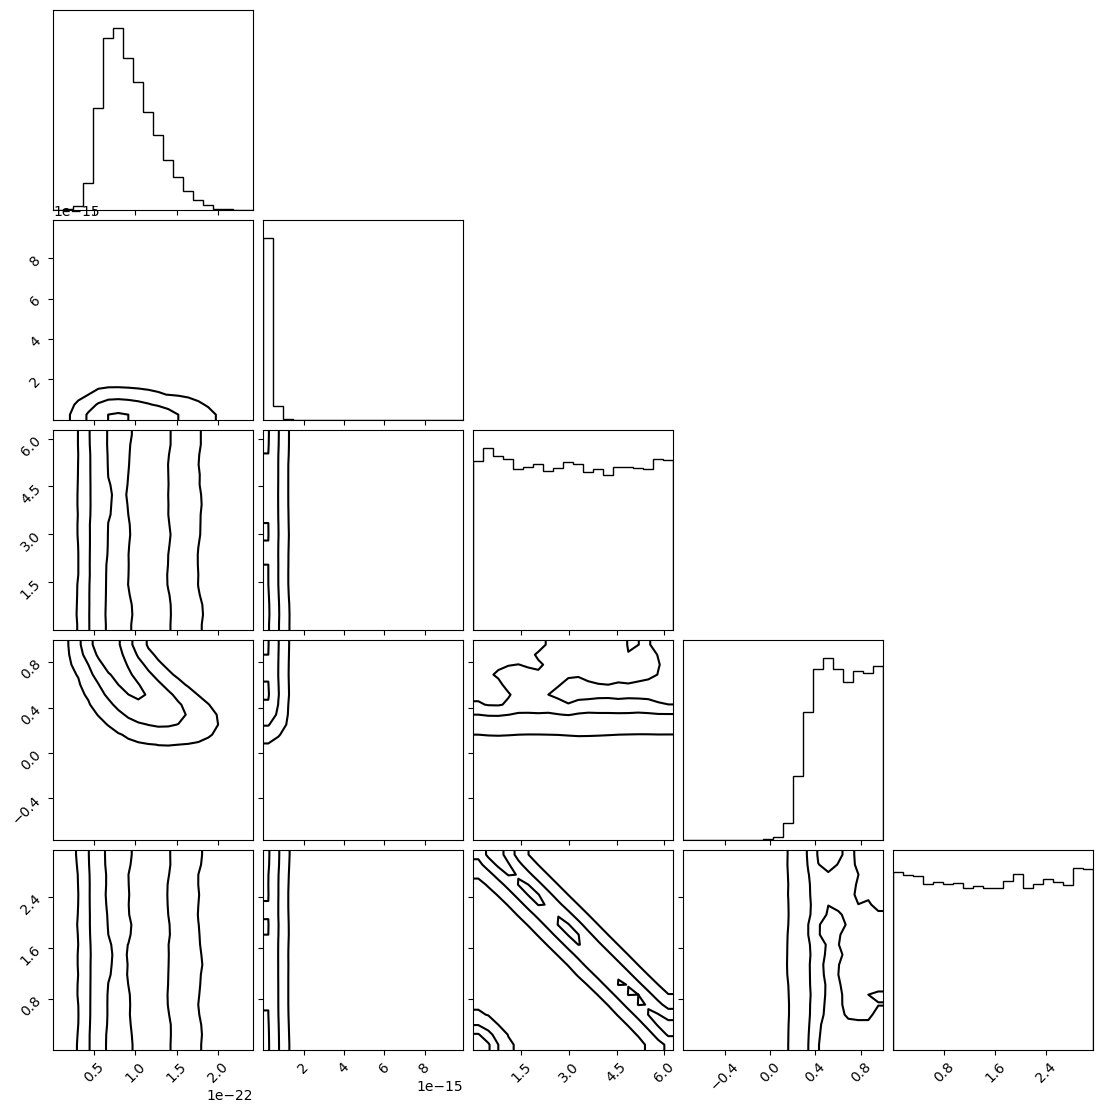

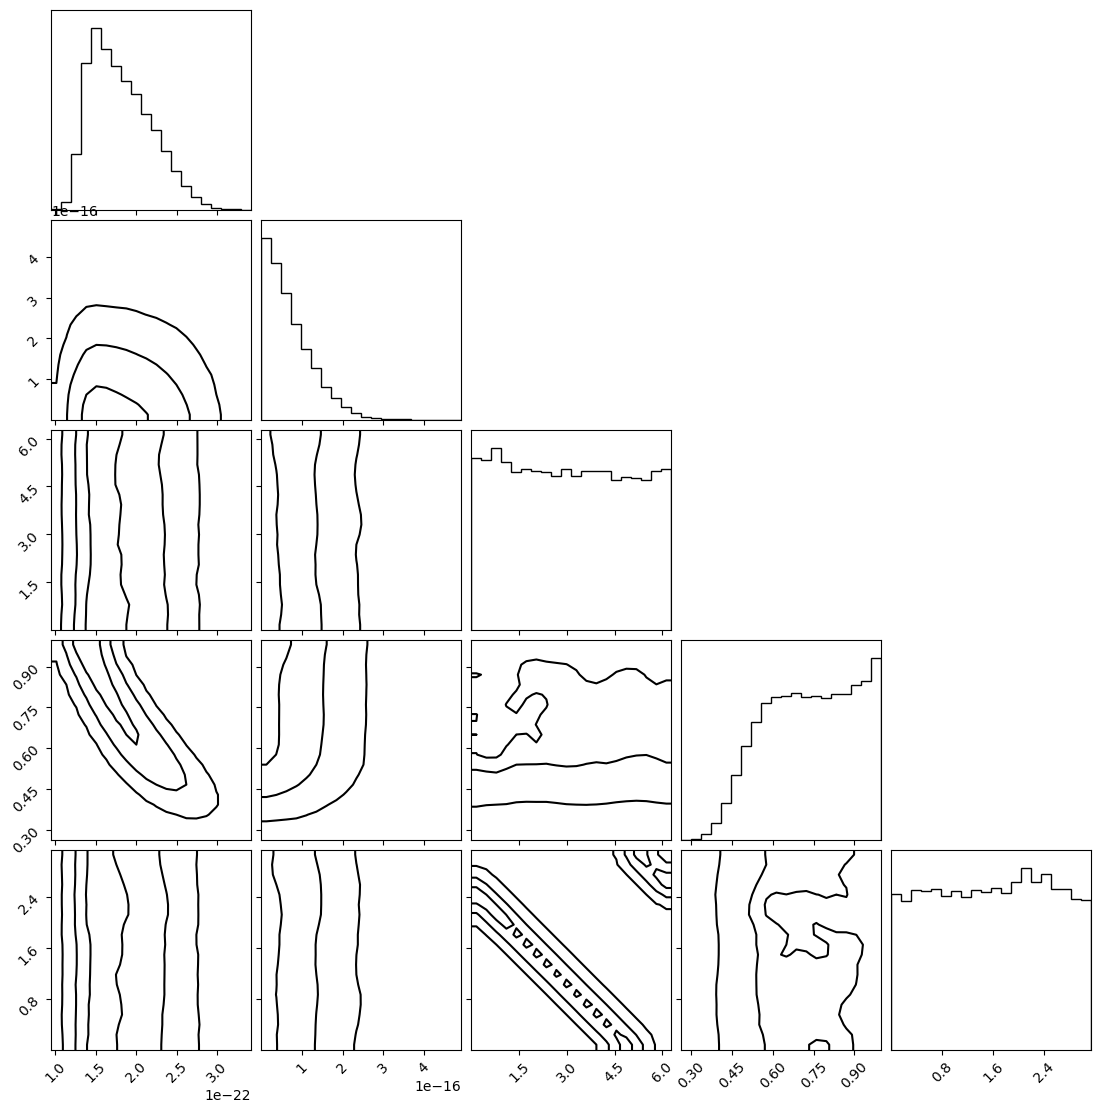

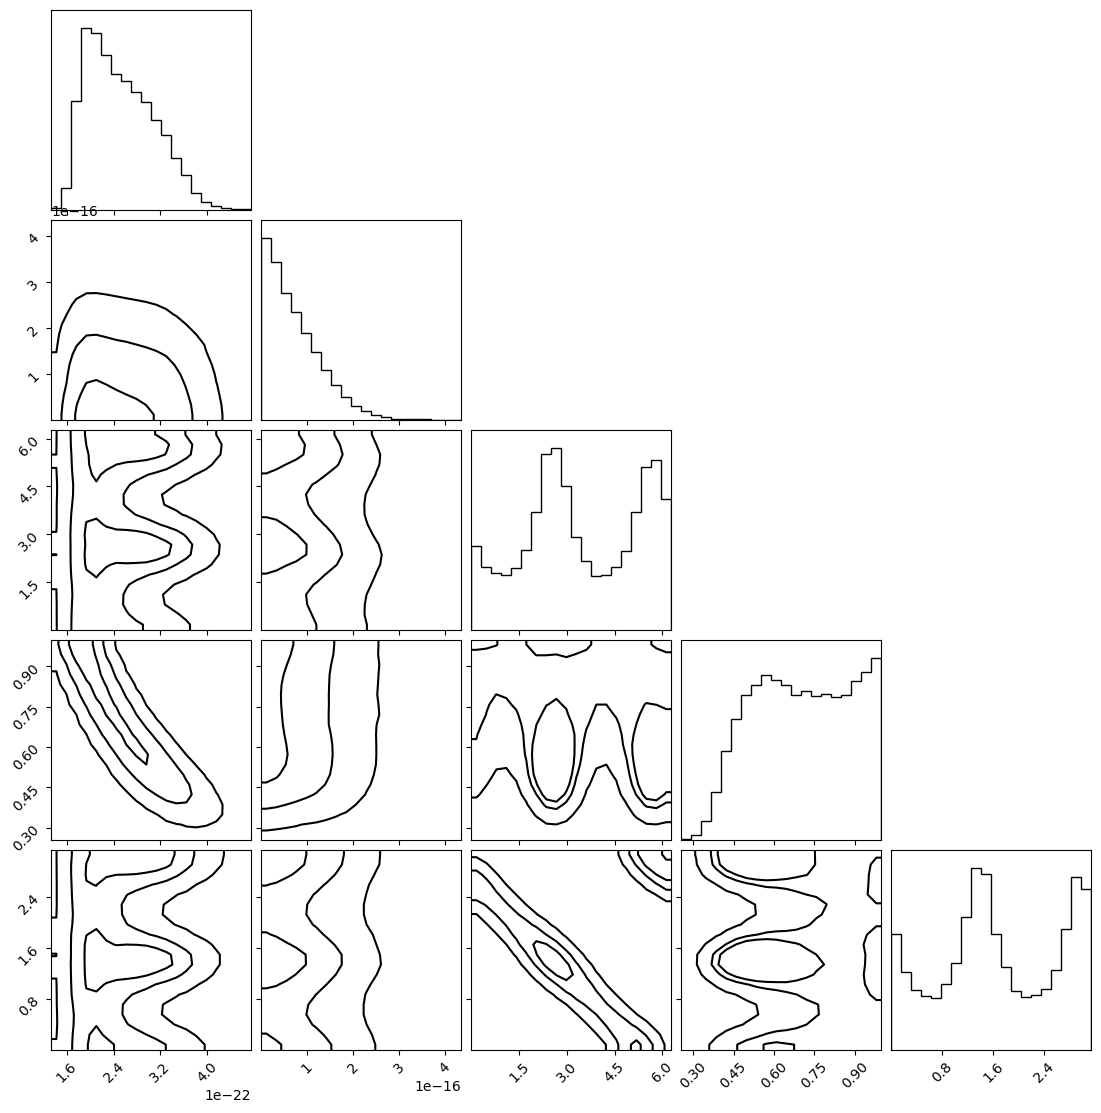

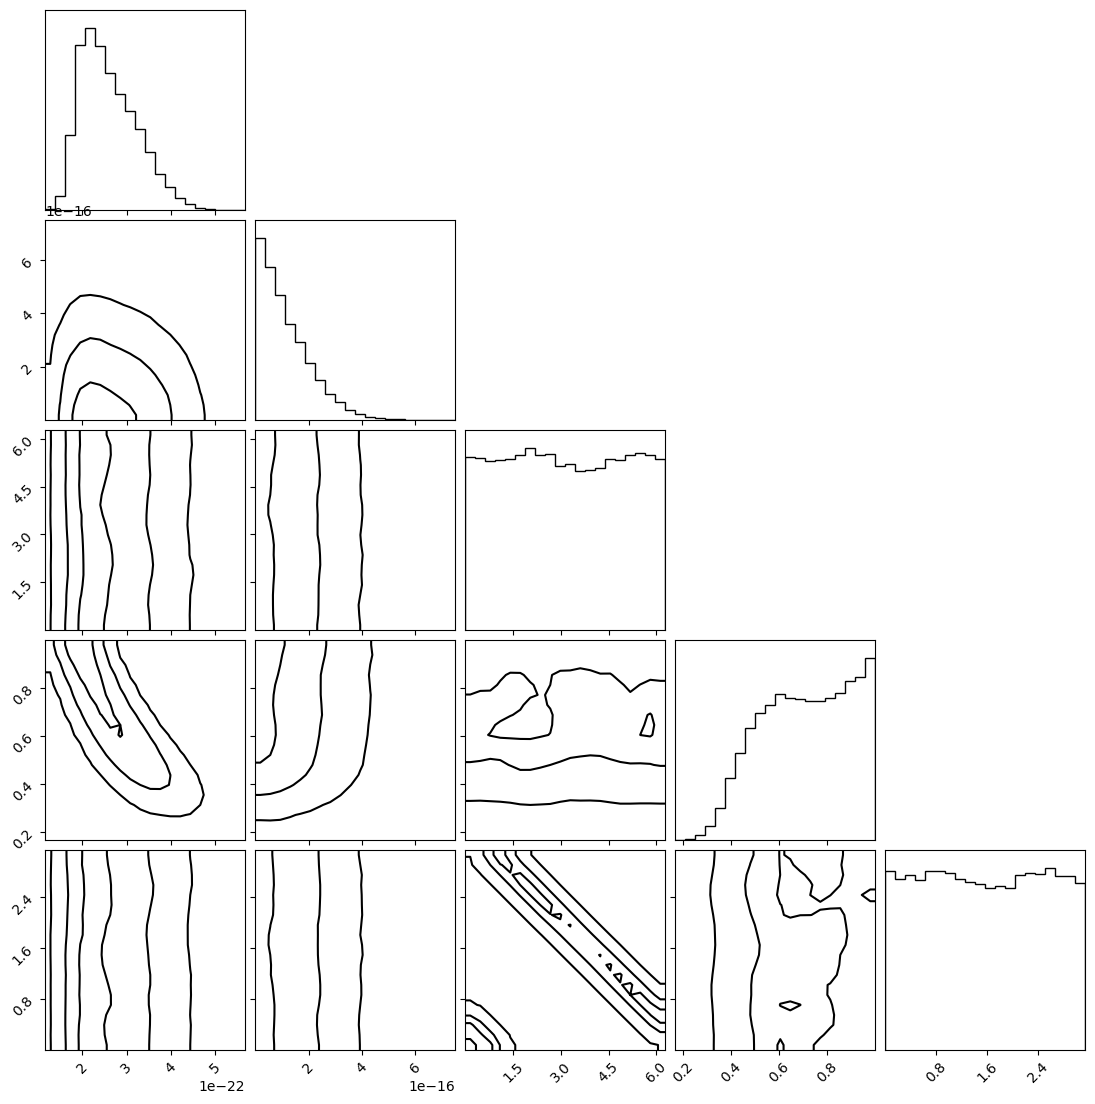

In [8]:
run_posterior_estimate_vgbs(our_vgbs,
                            nsteps = 4000,
                            burn = 5000,
                            filename_base = "vgb_sample_storage",
                            overwrite = False,
                            Tobs = Tobs,
                            dt = dt,
                            noise = noise,
                           )

### display results

In [9]:
mcmc_fnames = [f"vgb_sample_storage_{c}.h5" for c in clean_names]
fractional_errors_mcmc = []
found_names = []
for clean_name, fname in zip(clean_names, mcmc_fnames):
    if not os.path.exists(fname):
        print(f"{clean_name} output file ({fname}) not found. Skipping...")
        continue
    found_names.append(clean_name)
    with h5py.File(fname,'r') as f:
        # shape goes like (nsamples, ntemps, nwalkers, nleaves, ndim)
        # we pick cold chain, ignore leaf axis, and pick param 0 (amplitude)
        amp_samples = np.array(f['mcmc/chain/gb'][:,0,:,0,0])
        fractional_errors_mcmc.append(np.std(amp_samples) / np.mean(amp_samples))
fractional_errors_mcmc = np.array(fractional_errors_mcmc)
extra_Tobs_to_10_perc = (fractional_errors_mcmc / 0.1)**2
extra_Tobs_to_30_perc = (fractional_errors_mcmc / 0.3)**2
df_results = pd.DataFrame({
    'Name': found_names,
    'AmplitudeFractionalErrorOneYear': fractional_errors_mcmc,
    'YearsToTenPercent' : extra_Tobs_to_10_perc * Tobs / (1.0 * YRSID_SI),
    'YearsToThirtyPercent' : extra_Tobs_to_30_perc * Tobs / (1.0 * YRSID_SI)
                          })
df_results.to_csv("spr1.csv",index=False)
df_results

MCVn output file (vgb_sample_storage_MCVn.h5) not found. Skipping...
DSSJ1908 output file (vgb_sample_storage_DSSJ1908.h5) not found. Skipping...
PLib output file (vgb_sample_storage_PLib.h5) not found. Skipping...
803Cen output file (vgb_sample_storage_803Cen.h5) not found. Skipping...
0526+5934 output file (vgb_sample_storage_0526+5934.h5) not found. Skipping...
MCnc output file (vgb_sample_storage_MCnc.h5) not found. Skipping...


,Name,AmplitudeFractionalErrorOneYear,YearsToTenPercent,YearsToThirtyPercent


## SPR-2: LISA shall conduct a census of UCBs with GW frequency between 5 and 20 mHz complete to S/N>10 after T months.

FOM 1: Using an input population (currently from LDC-2) compute the S/N for each UCB above 5 mHz and tally the number that exceed the detection threshold. Compare that to the total number of input binaries.

FOM 2: CDFs and survival function of match between Global Fit catalog and input population, with the total number from FOM 1 included on the survival function plot to assess how well the prototype pipelines are performing relative to this SPR



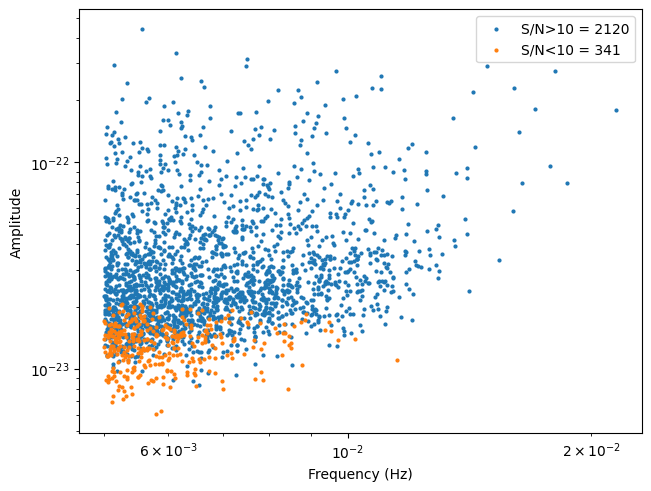

In [10]:
# 
# read in LDC-2 population and compute S/N
#

params = np.load("ldc2a_inj.npy")
params = params[params["Frequency"] < 0.035]
freqs_out = []
amps_out  = []
snrs_out  = []

for j in range(len(params)):
    gb_par = params[j]
    params_in = np.array([
        gb_par["Amplitude"],
        gb_par["Frequency"],
        gb_par["FrequencyDerivative"],
        0.0,
        gb_par["InitialPhase"],
        gb_par["Inclination"],
        gb_par["Polarization"],
        gb_par["EclipticLongitude"],
        gb_par["EclipticLatitude"]
    ])
    
    snrs_out.append(calculators["gb"].get_snr(*params_in, tdi2=False))
    freqs_out.append(gb_par["Frequency"])
    amps_out.append(gb_par["Amplitude"])
    
snrs_out  = np.asarray(snrs_out)
freqs_out = np.asarray(freqs_out)
amps_out  = np.asarray(amps_out)

#get number of binaries with S/N > 10
found  = len(snrs_out[snrs_out > 10.0])
missed = len(snrs_out[snrs_out <= 10.0])

fig, ax = plt.subplots(layout='constrained')

ax.scatter(freqs_out[snrs_out > 10.0], amps_out[snrs_out > 10.0], color="C0", s=4, label="S/N>10 = "+str(found))
ax.scatter(freqs_out[snrs_out < 10.0], amps_out[snrs_out < 10.0], color="C1", s=4, label="S/N<10 = "+str(missed))
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc="upper right")

fig.savefig("spr2.png", dpi=150)


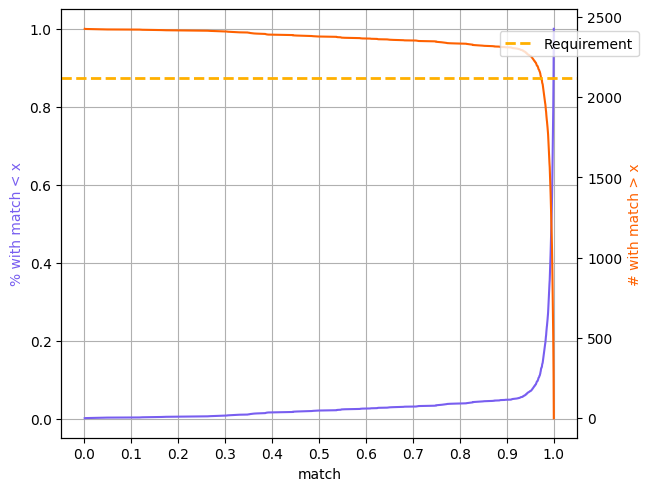

In [11]:
# read in Global Fit catalog match results
df = pd.read_csv('glass_ldc2a_ucb_match.dat',delimiter=' ',names=['match','snr','f'])

# filter out low-f sources
df = df[(df['f']>0.005)]

# sort match column
match = df['match']
match = np.sort(match)
cdf = np.arange(1, len(match) + 1) / len(match)
survival = len(match)-np.arange(1, len(match) + 1) 

COLOR_CDF = "#785EF0"
COLOR_SURVIVAL = "#FE6100"

fig, ax = plt.subplots(layout='constrained')

# plot the CDF
ax.plot(match, cdf, color=COLOR_CDF)
ax.set_ylabel('% with match < x', color=COLOR_CDF)
ax.set_xlabel('match')
ax.set_xticks(np.arange(0, 1.1, step=0.1))
ax.grid(True)

# add the survival function to the plot
ax2 = ax.twinx()
ax2.plot(match, survival, color=COLOR_SURVIVAL)
ax2.axhline(y=found, color='#FFB000', linestyle='--', linewidth=2, label='Requirement')

# add the requirement to the survival function line
ax2.set_ylabel('# with match > x', color=COLOR_SURVIVAL)
fig.legend(bbox_to_anchor=(1.0, 0.96), loc='upper right')

fig.savefig("spr2v.png", dpi=150)


## SPR-3: LISA shall conduct a survey of MBH mergers with individual masses between 5e4 and 1e7 M⊙ complete to DL<60 Gpc (z<6); and masses between 1e7 and 1e8 M⊙ complete to DL<16 Gpc (z<2.3)

FOM 1: CDFs of S/Ns from Monte Carlo simulation of MBHs in different mass/distance bins with lines indicating detection threshold (S/N > 10) and completeness (90%) [TBC]

In [12]:
# 
# Set up Monte Carlo
#

snr_lim = 10.0    # Detection threshold
requirement = 0.9 # Completeness requirement
draws = 1024      # Number of draws in the Monte Carlo
qmin = 0.05       # minimum mass ratio for Monte Carlo


In [14]:
# 
# Setup BBHx waveform generator
#

# for transforms
fill_dict_mbh = {6: 0.0}

# transforms from pe to waveform generation
parameter_transforms_mbh = {
    0: np.exp,
    4: lambda x: x * 1e9 * PC_SI,
    7: np.arccos,
    9: np.arcsin,
    (0, 1): lambda mT, q: (mT / (1 + q), mT * q / (1 + q))
}

input_basis = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11]
output_basis = list(range(12))

transform_fn_mbh = TransformContainer(
    input_basis,
    output_basis,
    parameter_transforms=parameter_transforms_mbh,
    fill_dict=fill_dict_mbh,
)


z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 2.3, dL: 18.877546494144855 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc
z: 6.0, dL: 58.975700104533814 Gpc


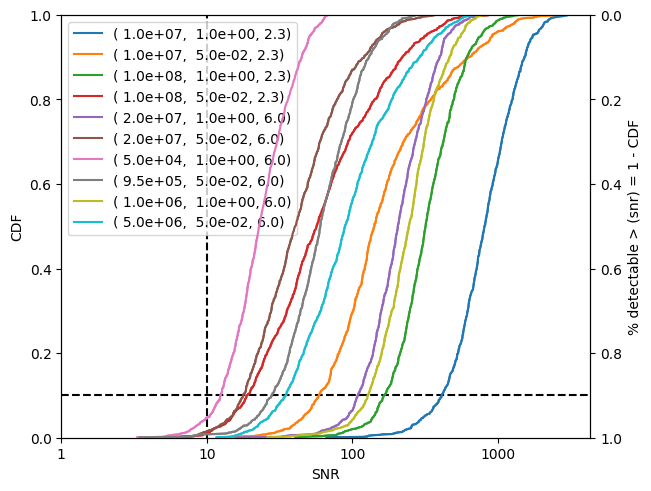

In [15]:
# priors
priors_mbh = ProbDistContainer({
    0: uniform_dist(np.log(1e4), np.log(1e8)),
    1: uniform_dist(0.1, 0.999999999),
    2: uniform_dist(-0.99999999, +0.99999999),
    3: uniform_dist(-0.99999999, +0.99999999),
    4: uniform_dist(0.01, 1000.0),
    5: uniform_dist(0.0, 2 * np.pi),
    6: uniform_dist(-1.0 + 1e-6, 1.0 - 1e-6),
    7: uniform_dist(0.0, 2 * np.pi),
    8: uniform_dist(-1.0 + 1e-6, 1.0 - 1e-6),
    9: uniform_dist(0.0, np.pi),
    10: uniform_dist(0.0, Tobs + 3600.0),
})

# set up cdf figure
plt.close()
fig, ax = plt.subplots(layout='constrained')
ax.axvline(np.log10(snr_lim), color="k", ls="--")
ax.axhline(1 - requirement, color="k", ls="--")
ax2 = ax.twinx()

# the monte carlo
# TODO: This monte carlo is using redshift and converting to DL. We should be using DL and converting to redshift (just for kicks)
injs = [(1e7, 0.99999, 2.3), (1e7, qmin, 2.3), (1e8, 0.99999, 2.3), (1e8, qmin, 2.3), (2e7, 0.99999, 6.0), (2e7, qmin, 6.0), (5e4, 0.99999, 6.0), (9.5e5, qmin, 6.0), (1e6, 0.99999, 6.0), (5e6, qmin, 6.0)]
for i, (M, q, z) in enumerate(injs):
    new_systems = transform_fn_mbh.both_transforms(priors_mbh.rvs(size=draws))

    m1 = M / (1 + q)
    m2 = M * q / (1 + q)
    new_systems[:, 0] = m1
    new_systems[:, 1] = m2
    dL = Planck18.luminosity_distance(z).to(u.m).value
    print(f"z: {z}, dL: {Planck18.luminosity_distance(z).to(u.Gpc)}")
    new_systems[:, 4] = dL
    
    snrs_out = np.zeros(draws)
    for j in range(draws):
        snrs_out[j] = calculators["bbh"].get_snr(*new_systems[j], freqs=np.logspace(-4, 0, 1024))
    
    log10_snrs_out = np.log10(snrs_out.copy())

    cdf = np.arange(1, log10_snrs_out.shape[0] + 1) / log10_snrs_out.shape[0]
    det_frac = 1 - cdf
    x = np.sort(snrs_out)
        
    ax.plot(np.log10(x), cdf, color=f"C{i}", label=f"({M: .01e}, {q: .01e}, {z})")
    ax2.plot(np.log10(x), det_frac, color=f"C{i}", label=f"({M: .01e}, {q: .01e}, {z})")

# format the plot and save
ax2.set_ylim(1.0, 0.0)
ax.set_ylim(0.0, 1.0)
ax2.set_ylabel('% detectable > (snr) = 1 - CDF')
ax.set_xlabel("SNR")
ax.set_xticks(np.log10([1, 10, 100, 1000]))
ax.set_xticklabels([1, 10, 100, 1000])
ax.set_ylabel("CDF")
ax.legend()
fig.savefig("spr3.png")

## SPR-4: LISA shall conduct a survey of EMRI signals, which is complete for the following parameter ranges: the MBH has rest-frame mass [TBC] in the range 3e5 to 1e6 M⊙; the secondary body has rest-frame mass > 10 M⊙; the final plunge occurs after the first 3 months and before the end of the survey; the orbital eccentricity at plunge is < 0.2; and DL<1 Gpc.

FOM 1: CDFs of S/N from Monte Carlo simulations of EMRIs in different mass bins with lines indicating detection threshold (S/N > 30) and completeness (90%) [TBC]

/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

17.805247646421403


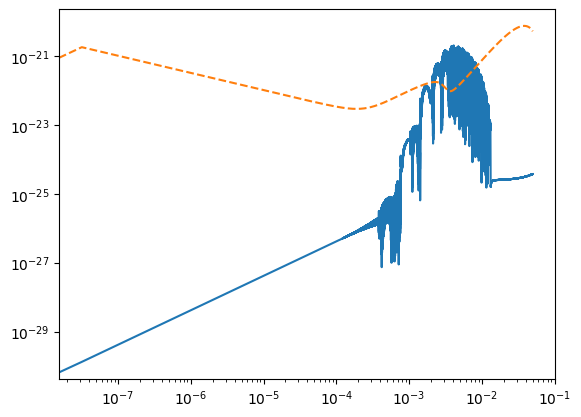

In [4]:
M = 1e6
mu = 1e1
a = 0.2
p0 = 7.0  # will integrate backwards (see below for getting separatrix)
e0 = 0.2
x0 = 1.0
dist = 3.0
phiS = 0.4423
qS = 0.523023
qK = 0.8923123
phiK = 0.1221209312
Phi_phi0 = 0.1231232
Phi_theta0 = 4.234903824
Phi_r0 = 3.230923

emri_injection_params = np.array(
    [M, mu, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
)

fn = np.fft.rfftfreq(Nobs, dt)
print(calculators["emri"].get_snr(*emri_injection_params))
emri_freqs = np.fft.rfftfreq(calculators["emri"].last_output[0].shape[0], calculators["emri"].aet_template_gen.dt)
Sn = get_sensitivity(emri_freqs, model=scirdv1, sens_fn=A1TDISens, **psd_kwargs)
plt.loglog(emri_freqs, emri_freqs * np.abs(np.fft.rfft(calculators["emri"].last_output[0])) * calculators["emri"].aet_template_gen.dt, c=f"C0")
plt.loglog(emri_freqs, np.sqrt(emri_freqs) * (Sn) ** (1/2), c=f"C1", ls="--")


In [5]:
from eryn.prior import uniform_dist, ProbDistContainer
from eryn.utils import TransformContainer
from few.utils.geodesic import get_separatrix
from few.trajectory.ode import KerrEccEqFlux

# priors
priors_emri = ProbDistContainer({
    0: uniform_dist(np.log(1e5), np.log(1e6)),
    1: uniform_dist(10.0, 50.0),
    2: uniform_dist(0.0001, +0.95),
    3: uniform_dist(6.5, 9.0),  # this will be ignored
    4: uniform_dist(0.01, 0.3),
    5: uniform_dist(-1.0, 1.0), # this will be ignored up to picking prograde / retrograde
    6: uniform_dist(0.01, 10.0),
    7: uniform_dist(-0.99, 0.99),
    8: uniform_dist(0.0, 2 * np.pi),
    9: uniform_dist(-0.99, 0.99),
    10: uniform_dist(0.0, 2 * np.pi),
    11: uniform_dist(0.0, 2 * np.pi),
    12: uniform_dist(0.0, 2 * np.pi),
    13: uniform_dist(0.0, 2 * np.pi), 
})

 # for transforms
fill_dict_emri = None

# transforms from pe to waveform generation
parameter_transforms_emri = {
    0: np.exp,
    7: np.arccos,
    9: np.arccos,
}

input_basis = list(range(14))
output_basis = list(range(14))
transform_fn_emri = TransformContainer(
    input_basis, output_basis, 
    parameter_transforms=parameter_transforms_emri,
    fill_dict=fill_dict_emri,
)


In [ ]:
if not os.path.exists("EMRI_output_3.pickle"):
        
    
    draws = 32
    
    # TODO: change to source frame associated values
    masses = [(1e5, 10.0)]  # , (1e5, 10.0)]  # (1e7, 10.0), (1e6, 10.0), (1e5, 10.0), (5e5, 10.0), (5e6, 10.0), (3e5, 10.0)]
    dL = 1.0
    # fig, ax = plt.subplots(layout='constrained')
    
    snrs_out_dict = {}
    
    t_plunge_min = 0.5  # Years
    t_plunge_max = 2.0  # Years
    
    Delta_p = KerrEccEqFlux().separatrix_buffer_dist
    prograde = True
    xI = 1.0 if prograde else -1.0
    for i, (M, mu) in enumerate(masses):
        new_systems = transform_fn_emri.both_transforms(priors_emri.rvs(size=draws))
    
        t_plunge_new = np.random.uniform(t_plunge_min, t_plunge_max, size=draws)
    
        new_systems[:, 0] = M
        new_systems[:, 1] = mu
        # dL = Planck15.luminosity_distance(z).to(u.Gpc).value
        # print(f"z: {z}, dL: {Planck15.luminosity_distance(z).to(u.Gpc)}")
        
        new_systems[:, 6] = dL
    
        new_systems[:, 5] = xI
    
        a_all = new_systems[:, 2]
        e_all = new_systems[:, 4]
    
        p_sep = np.asarray([get_separatrix(a, e, xI) for a, e, in zip(a_all, e_all)])
        p0_all = p_sep + Delta_p  # the separatrix at the trajectory end-point.
    
        new_systems[:, 3] = p0_all
    
        snrs_out = np.zeros(draws)
        for j in range(draws):
            try:
                del emri, calc_new
            except NameError:
                pass
            
            # emri generator
            emri = EMRITDIWaveform(
                T=t_plunge_new[j], 
                dt=dt, 
                emri_waveform_kwargs=dict(inspiral_kwargs=dict(integrate_backwards=True)),
                response_kwargs=dict(tdi="1st generation", orbits=orbits_here)
            )
            
            calc_new = EMRICalculationController(
                emri, 
                scirdv1,
                psd_kwargs, 
                t_plunge_new[j],  # years
                dt,
                psd=A1TDISens
            )
            
            _snr = calc_new.get_snr(*new_systems[j])
            print(i, j, new_systems[j], _snr) 
            snrs_out[j] = _snr.copy()
        snrs_out_dict[(M, mu)] = snrs_out
    
    with open("EMRI_output_3.pickle", "wb") as fp:
        pickle.dump(snrs_out_dict, fp, pickle.HIGHEST_PROTOCOL)

else:
    print("Not running emri calculations")

/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/Users/mlkatz/Research/envs/proj_sci_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np

0 0 [1.00000000e+05 1.00000000e+01 6.73016302e-01 3.78456135e+00
 2.13761132e-01 1.00000000e+00 1.00000000e+00 1.32802908e+00
 2.92064489e+00 2.36769482e+00 2.07945657e+00 5.01379517e+00
 4.10922329e+00 2.33257284e+00] 12.149167333651308
0 1 [1.00000000e+05 1.00000000e+01 4.42131197e-01 4.77168557e+00
 2.04609220e-01 1.00000000e+00 1.00000000e+00 7.61140050e-01
 1.20980580e+00 1.50129805e+00 5.36564680e-01 3.81346380e+00
 3.03527667e+00 4.39582046e+00] 13.026053481414877
0 2 [1.00000000e+05 1.00000000e+01 6.03116673e-01 4.03442205e+00
 1.62977169e-01 1.00000000e+00 1.00000000e+00 3.10534720e-01
 4.25042886e+00 1.17917298e+00 4.76100146e+00 5.14301178e+00
 5.44220625e+00 2.69015439e+00] 23.303867509629434
0 3 [1.00000000e+05 1.00000000e+01 5.82076355e-01 4.08286338e+00
 1.31870733e-01 1.00000000e+00 1.00000000e+00 2.01711080e+00
 5.65432648e+00 1.13591124e+00 3.66275634e+00 1.25615570e+00
 3.81777802e+00 2.65681053e+00] 22.995042610373947
0 4 [1.00000000e+05 1.00000000e+01 6.82616725e-0

In [4]:
# form up CDFs
with open("EMRI_output.pickle", "rb") as fp:
    snrs_out_dict = pickle.load(fp)

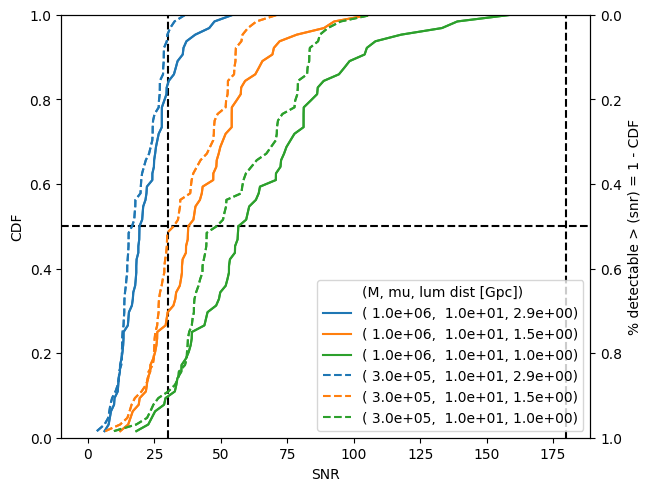

In [7]:
snr_lim = 30.0    # Detection threshold
requirement = 0.5 # Completeness requirement
# monte carlo high mass primary

plt.close()
fig, ax = plt.subplots(layout='constrained')
ax.axvline(snr_lim, color="k", ls="--")
ax.axvline(snr_lim * 6, color="k", ls="--")
ax.axhline(1 - requirement, color="k", ls="--")
ax2 = ax.twinx()
ax.plot([-1.0, -1.0], [-1.0, -2.0], color="white", label="(M, mu, lum dist [Gpc])")

dist_redshift_1 = Planck18.luminosity_distance(1.0).to(u.Gpc).value
dist_redshift_05 = Planck18.luminosity_distance(0.5).to(u.Gpc).value
check = {}
for i, M in enumerate([1e6, 3e5]):
    for j, dist in enumerate([dist_redshift_05,  1.5, 1.0]):
        mu = 1e1
        # dist = 1.0  # Gpc (choose hear)
        
        snrs_out = snrs_out_dict[(M, mu)] / dist
        
        # log10_snrs_out = np.log10(snrs_out.copy() )
        cdf = np.arange(1, snrs_out.shape[0] + 1) / snrs_out.shape[0]
        det_frac = 1 - cdf
        x = np.sort(snrs_out)
        check[(M, dist)] = [x, cdf]
        ls = ["solid", "dashed"][i]
        color = f"C{j}"
        ax.plot(x, cdf, color=color, ls=ls, label=f"({M: .01e}, {mu: .01e}, {dist:.01e})")
        ax2.plot(x, det_frac, color=color, ls=ls, label=f"({M: .01e}, {mu: .01e}, {dist:.01e})")

ax2.set_ylim(1.0, 0.0)
ax.set_ylim(0.0, 1.0)
ax2.set_ylabel('% detectable > (snr) = 1 - CDF')
ax.set_xlabel("SNR")
# ax.set_xticks(np.log10([1, 10, 100, 1000]))
# ax.set_xticklabels([1, 10, 100, 1000])
ax.set_ylabel("CDF")
ax.legend()
fig.savefig("emri_cdf_new.png")

## SPR-5: LISA shall identify and characterize new MBH sources within 36 hours of the GW signal integrated S/N greater than 10 at the constellation.

FOM 1: Benchmarking results from running prototype online search pipelines.

In [ ]:
# write a prototype online search pipeline